In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import kpss

In [191]:
s='maize'

In [192]:
df=pd.read_csv("DATA/Backup/"+s+".csv")

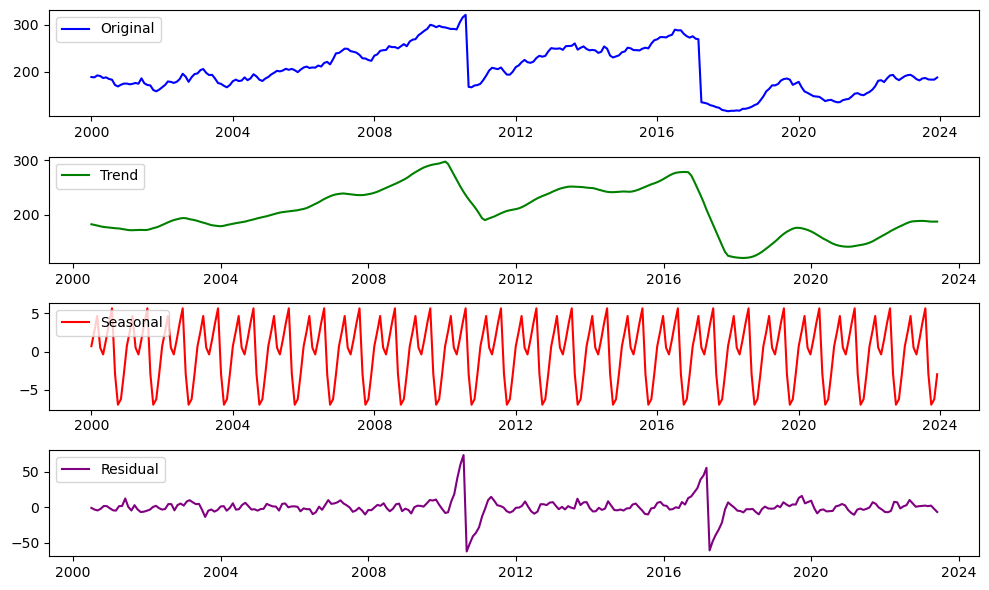

In [193]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Assuming df is your DataFrame with a 'date' column and a 'value' column representing the time series
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Perform seasonal decomposition
decomposition = seasonal_decompose(df['price'], model='additive')

# Plot the original time series
plt.figure(figsize=(10, 6))
plt.subplot(411)
plt.plot(df['price'], label='Original', color='blue')
plt.legend(loc='upper left')

# Plot the trend component
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='green')
plt.legend(loc='upper left')

# Plot the seasonal component
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal', color='red')
plt.legend(loc='upper left')

# Plot the residual component
plt.subplot(414)
plt.plot(decomposition.resid, label='Residual', color='purple')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [194]:
import tensorflow as tf
m1=tf.keras.models.load_model(s+'_lstm')
print(m1.layers[0].input_shape)
m2=tf.keras.models.load_model(s+'_bi_lstm')
print(m2.layers[0].input_shape)
m3=tf.keras.models.load_model(s+'_stacked_lstm')
print(m3.layers[0].input_shape)
m4=tf.keras.models.load_model(s+'_gru')
print(m4.layers[0].input_shape)
m5=tf.keras.models.load_model(s+'_cnn')
print(m5.layers[0].input_shape)

(None, 1, 1)
(None, 3, 1)
(None, 1, 1)
(None, 1, 1)
(None, 3, 1)


In [195]:
import pandas as pd
from scipy.stats import mstats
def winsorize_outliers(series, lower_percentile=0.05, upper_percentile=0.95):
    lower_limit = series.quantile(lower_percentile)
    upper_limit = series.quantile(upper_percentile)
    winsorized_values = mstats.winsorize(series, limits=(lower_percentile, 1 - upper_percentile))
    return winsorized_values

In [198]:
df=pd.read_csv("DATA/Backup/"+s+".csv")
scaler = MinMaxScaler(feature_range=(0, 1))
df['price'] = scaler.fit_transform(df['price'].values.reshape(-1,1))
df['price1'] = winsorize_outliers(df['price'], lower_percentile=0.05, upper_percentile=0.95)
df.pop('price')
df['price']=df.pop('price1')
shift=3
for i in range(shift,0,-1):
    df['target-'+str(i)] = df['price'].shift(i)
d=df[shift:]

def windowed_df_to_date_X_y(windowed_dataframe):
    df_as_np = windowed_dataframe.to_numpy()
    dates = df_as_np[:, 0]
    middle_matrix = df_as_np[:, 2:]
    X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))
    Y = df_as_np[:, 1:2]
    return dates, X.astype(np.float32), Y.astype(np.float32)

dates, X, y = windowed_df_to_date_X_y(d)
dates.shape, X.shape, y.shape

q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)
dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]
dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

In [197]:
test_predictions_lstm = m1.predict(X_test)#.flatten()

test_predictions_Stacked_latm = m3.predict(X_test)#.flatten()
test_predictions_gru = m4.predict(X_test)#.flatten()


1/1 [==============================] - 0s 219ms/step


In [199]:
test_predictions_bi_lstm = m2.predict(X_test)#.flatten()
test_predictions_cnn = m5.predict(X_test)#.flatten()

1/1 [==============================] - 0s 29ms/step


In [200]:
lstm=scaler.inverse_transform(test_predictions_lstm.reshape(-1, 1))
bi_lstm=scaler.inverse_transform(test_predictions_bi_lstm.reshape(-1, 1))
stk_lstm=scaler.inverse_transform(test_predictions_Stacked_latm.reshape(-1, 1))
gru=scaler.inverse_transform(test_predictions_gru.reshape(-1, 1))
cnn=scaler.inverse_transform(test_predictions_cnn.reshape(-1, 1))
actual=scaler.inverse_transform(y_test.reshape(-1, 1))


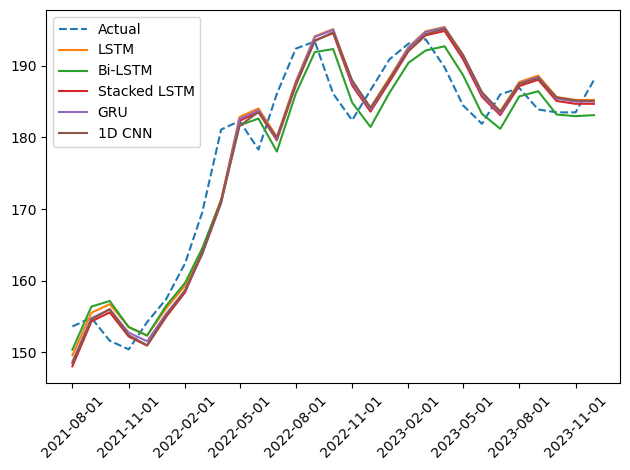

In [201]:
from matplotlib.dates import DateFormatter, MonthLocator
import matplotlib.pyplot as plt
dates_test = np.array([np.datetime64(date) for date in dates_test])
plt.plot(dates_test, actual,linestyle="--")
plt.plot(dates_test, lstm)
plt.plot(dates_test, bi_lstm)
plt.plot(dates_test, stk_lstm)
plt.plot(dates_test, gru)
plt.plot(dates_test, cnn)

plt.legend(['Actual', 
            'LSTM',
            'Bi-LSTM',
            'Stacked LSTM', 
            'GRU',
            '1D CNN'],loc='upper left')
plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('graph/'+s+'.png', dpi=500,bbox_inches='tight')
plt.show()

#plt.legend(['Testing Predictions', 'Testing Observations'])

In [202]:
def mase(y_true, y_pred):
    naive_forecast = np.roll(y_true, 1)
    naive_mae = np.mean(np.abs(y_true - naive_forecast))
    return mean_absolute_error(y_true, y_pred) / naive_mae

In [203]:
mase1 = mase(actual, lstm)
mase2 = mase(actual, bi_lstm)
mase3 = mase(actual, stk_lstm)
mase4 = mase(actual, gru)
mase5 = mase(actual, cnn)
print(mase1)
print(mase2)
print(mase3)
print(mase4)
print(mase5)

0.7577793
0.7257588
0.753973
0.76673406
0.76691777


In [204]:
# Calculate evaluation metrics
mse1 = mean_squared_error(actual,lstm)
mse2 = mean_squared_error(actual,bi_lstm)
mse3 = mean_squared_error(actual,stk_lstm)
mse4 = mean_squared_error(actual,gru)
mse5 = mean_squared_error(actual,cnn)
print(mse1)
print(mse2)
print(mse3)
print(mse4)
print(mse5)


19.00586
17.220675
18.908443
19.62252
19.43748


In [205]:
r1 = np.sqrt(mse1)
r2 = np.sqrt(mse2)
r3 = np.sqrt(mse3)
r4 = np.sqrt(mse4)
r5 = np.sqrt(mse5)

print(r1)
print(r2)
print(r3)
print(r4)
print(r5)

4.359571
4.1497803
4.348384
4.4297314
4.408796


In [206]:
r21 = r2_score(actual, lstm)
r22 = r2_score(actual, bi_lstm)
r23 = r2_score(actual, stk_lstm)
r24 = r2_score(actual, gru)
r25 = r2_score(actual, cnn)

print(r21)
print(r22)
print(r23)
print(r24)
print(r25)

0.9044889182776311
0.9134600967052823
0.9049784724061071
0.9013899855447087
0.9023198752822621
